# Forecasting County-Level Measles Outbreak Timing
**Notebook**: DeepSurv (continuous) + DeepHit (discrete sketch) + RSF baseline  
**Purpose**: implement neural survival models, evaluate (C-index, tAUC @ 3/6 months), and visualize risk & feature sensitivity.  
**Data**: Uses merged county monthly panel data from `data/processed/merged_county_month_panel.csv` (includes outbreak, demographics, vaccinations, import data, Google Trends).

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import datetime

# ML libs
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Required libs for baselines & evaluation
from lifelines.utils import concordance_index
import sksurv
from sksurv.ensemble import RandomSurvivalForest

In [2]:
def load_measles_data_from_panel(
        panel_path='../data/processed/merged_county_month_panel.csv',
        start_date='2020-01-01',
        end_date='2025-12-31'
    ):
    """
    Load merged county-month panel and convert to survival-analysis format.
    Keeps *all* columns with their original names (no prefix).
    
    Output: one row per county with:
        - county_fips
        - duration_months
        - event
        - event_month
        - start_month
        - ALL features from first observed month (original column names preserved)
    """

    print("Loading merged county monthly panel data...")
    panel_df = pd.read_csv(panel_path, low_memory=False)

    # Date handling - try different date column formats
    if 'month_period' in panel_df.columns:
        panel_df['date'] = pd.to_datetime(panel_df['month_period'], format='%Y-%m', errors='coerce')
    elif 'year' in panel_df.columns and 'month' in panel_df.columns:
        panel_df['date'] = pd.to_datetime(panel_df[['year', 'month']].assign(day=1))
    elif 'date' in panel_df.columns:
        panel_df['date'] = pd.to_datetime(panel_df['date'], errors='coerce')
    else:
        # Use month_index to create approximate dates
        panel_df['date'] = pd.to_datetime('2020-01-01') + pd.to_timedelta(panel_df['month_index'] * 30.44, unit='D')
    
    # Date filter
    start_dt, end_dt = pd.to_datetime(start_date), pd.to_datetime(end_date)
    panel_df = panel_df[panel_df['date'].between(start_dt, end_dt)]

    print(f"Panel data loaded: {len(panel_df)} county-month rows")

    # --- SURVIVAL DATASET -------------------------------------------------------
    county_rows = []

    for fips in panel_df['FIPS'].dropna().unique():
        sub = panel_df[panel_df['FIPS'] == fips].sort_values('date')

        if sub.empty:
            continue

        # Establish time origin
        sub = sub[sub['month_index'].notna()]
        if sub.empty:
            continue

        start_idx = sub['month_index'].min()

        # Determine event
        outbreak = sub[sub['event'] == 1]
        if not outbreak.empty:
            first_evt = outbreak.iloc[0]
            evt_idx = first_evt['month_index']
            duration = int(max(1, evt_idx - start_idx + 1))
            event = 1
            evt_month = int(first_evt['month']) - 1 if 'month' in first_evt else int(evt_idx % 12)
        else:
            last_idx = sub['month_index'].max()
            duration = int(max(1, last_idx - start_idx + 1))
            event = 0
            evt_month = None

        # Determine baseline row (first record)
        base = sub.iloc[0]

        # Build base dictionary with original column names
        row = {
            'county_fips': fips,
            'duration_months': duration,
            'event': event,
            'start_month': int(base['month']) - 1 if 'month' in base else int(base['month_index'] % 12),
            'event_month': (evt_month if evt_month is not None else int(base['month']) - 1
                            if 'month' in base else int(base['month_index'] % 12))
        }

        # --- ADD ALL COLUMNS with original names ----------------------------
        # Keep everything EXCEPT metadata columns
        exclude = {'FIPS', 'cases', 'event', 'date', 'month_index', 'month_period', 'year', 'month'}
        for col in base.index:
            if col not in exclude:
                # Use original column name (no prefix)
                row[col] = base[col]

        county_rows.append(row)

    df = pd.DataFrame(county_rows)

    # --- Sanity checks ----------------------------------------------------------
    df = df[df['duration_months'].notna() & np.isfinite(df['duration_months'])]
    df['duration_months'] = df['duration_months'].clip(upper=120)  # safety cap

    print(f"Loaded {len(df)} counties")
    print(f"Events: {df['event'].sum()} ({df['event'].mean()*100:.1f}%)")
    print(f"Duration range: {df['duration_months'].min()}–{df['duration_months'].max()}")
    print(f"Total columns: {len(df.columns)}")

    return df

df = load_measles_data_from_panel()
df.head()


Loading merged county monthly panel data...
Panel data loaded: 28998 county-month rows
Loaded 3222 counties
Events: 181 (5.6%)
Duration range: 1–9
Total columns: 2128


,county_fips,duration_months,event,start_month,event_month,state_name,DP02_0001E,DP02_0001M,DP02_0002E,DP02_0002M,...,vacc_coverage,google_trend,gt_dma_measles,gt_dma_mmr_vaccine,gt_dma_measles_virus,gt_dma_koplik_spots,intl_passengers,sin_season,cos_season,intl_passengers_lag1
0,1001,9,0,0,0,Alabama,22523.0,431.0,11861.0,633.0,...,NaN,7.0,61.0,37.25,0.833333,1.25,21489894.0,0.5,0.866025,NaN
1,1003,9,0,0,0,Alabama,94642.0,1316.0,53118.0,1615.0,...,NaN,7.0,61.0,37.25,0.833333,1.25,21489894.0,0.5,0.866025,NaN
2,1005,9,0,0,0,Alabama,9080.0,315.0,3572.0,287.0,...,NaN,7.0,61.0,37.25,0.833333,1.25,21489894.0,0.5,0.866025,NaN
3,1007,9,0,0,0,Alabama,7571.0,288.0,3971.0,359.0,...,NaN,7.0,61.0,37.25,0.833333,1.25,21489894.0,0.5,0.866025,NaN
4,1009,9,0,0,0,Alabama,21977.0,403.0,12090.0,555.0,...,NaN,7.0,61.0,37.25,0.833333,1.25,21489894.0,0.5,0.866025,NaN


In [3]:
# Preprocess: impute + scale, and split (stratify on event)
# Select ALL numeric features (exclude metadata columns)
exclude_cols = {'county_fips', 'duration_months', 'event', 'start_month', 'event_month', 'FIPS', 'cases', 'date', 'month_index', 'month_period', 'year', 'month', 'state_name'}
# Get all columns that are numeric
all_cols = [col for col in df.columns if col not in exclude_cols]
# Filter to only numeric columns (or columns that can be converted to numeric)
numeric_cols = []
for col in all_cols:
    # Try to convert to numeric
    try:
        test_series = pd.to_numeric(df[col], errors='coerce')
        # Check if at least some values are numeric (not all NaN)
        if test_series.notna().sum() > 0:
            numeric_cols.append(col)
    except:
        pass

features = numeric_cols

print(f"Selected {len(features)} numeric features")
print(f"First 10 features: {features[:10]}")

X = df[features].copy()
y_time = df['duration_months'].values
y_event = df['event'].values.astype(int)

# Convert to numeric, coercing errors to NaN
for col in features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Remove columns that are all NaN (can't be imputed)
valid_features = [col for col in features if X[col].notna().sum() > 0]
if len(valid_features) < len(features):
    print(f"Warning: Removed {len(features) - len(valid_features)} features with all NaN values")
    features = valid_features
    X = X[features]

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)
X = pd.DataFrame(X_scaled, columns=features)

X_train, X_temp, t_train, t_temp, e_train, e_temp = train_test_split(
    X, y_time, y_event, test_size=0.3, stratify=y_event, random_state=42
)
X_val, X_test, t_val, t_test, e_val, e_test = train_test_split(
    X_temp, t_temp, e_temp, test_size=0.5, stratify=e_temp, random_state=42
)

print("Train size:", X_train.shape[0])
print("Val size:", X_val.shape[0])
print("Test size:", X_test.shape[0])
print("Event rate (train):", e_train.mean(), "val:", e_val.mean(), "test:", e_test.mean())


Selected 1929 numeric features
First 10 features: ['DP02_0001E', 'DP02_0001M', 'DP02_0002E', 'DP02_0002M', 'DP02_0003E', 'DP02_0003M', 'DP02_0004E', 'DP02_0004M', 'DP02_0005E', 'DP02_0005M']
Train size: 2255
Val size: 483
Test size: 484
Event rate (train): 0.05631929046563193 val: 0.055900621118012424 test: 0.05578512396694215


### Continuous-time model (DeepSurv)

In [4]:
# Simple MLP for DeepSurv (continuous Cox partial likelihood)
class MLPNet(nn.Module):
    def __init__(self, in_features, layers=[64,32], dropout=0.2):
        super().__init__()
        mods = []
        prev = in_features
        for h in layers:
            mods += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(dropout)]
            prev = h
        mods.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*mods)
    def forward(self, x):
        return self.net(x).squeeze(-1)

def cox_ph_loss(preds, times, events):
    # preds, times, events are torch tensors (1d)
    order = torch.argsort(times, descending=True)
    preds_ord = preds[order]
    events_ord = events[order]
    cumsum = torch.logcumsumexp(preds_ord, dim=0)
    event_mask = events_ord > 0.5
    lhs = preds_ord[event_mask]
    rhs = cumsum[event_mask]
    neg_ll = -torch.sum(lhs - rhs)
    return neg_ll / events.sum().clamp(min=1.0)

def train_deepsurv(X_train, t_train, e_train, X_val, t_val, e_val,
                   layers=[64,32], dropout=0.2, lr=1e-3, batch_size=128, epochs=50, device='cpu'):
    device = torch.device(device)
    Xtr = torch.tensor(X_train.values.astype(np.float32)).to(device)
    y_t_tr = torch.tensor(t_train.astype(np.float32)).to(device)
    y_e_tr = torch.tensor(e_train.astype(np.float32)).to(device)
    Xv = torch.tensor(X_val.values.astype(np.float32)).to(device)
    y_t_v = torch.tensor(t_val.astype(np.float32)).to(device)
    y_e_v = torch.tensor(e_val.astype(np.float32)).to(device)

    model = MLPNet(X_train.shape[1], layers=layers, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    best_val = 1e9
    best_state = None
    for epoch in range(1, epochs+1):
        model.train()
        opt.zero_grad()
        preds_tr = model(Xtr)
        loss = cox_ph_loss(preds_tr, y_t_tr, y_e_tr)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            preds_v = model(Xv)
            val_loss = cox_ph_loss(preds_v, y_t_v, y_e_v).item()

        if epoch % 10 == 0 or epoch==1:
            print(f"Epoch {epoch:03d} - train loss: {loss.item():.6f}, val loss: {val_loss:.6f}")
        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict().copy()
    model.load_state_dict(best_state)
    return model

# Train for a small number of epochs to show intermediate output (increase for real training)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_ds = train_deepsurv(X_train, t_train, e_train, X_val, t_val, e_val,
                          layers=[128,64], dropout=0.2, lr=1e-3, epochs=60, device=device)


Epoch 001 - train loss: 9.249471, val loss: 5.604166
Epoch 010 - train loss: 6.852963, val loss: 5.200088
Epoch 020 - train loss: 6.489133, val loss: 4.944314
Epoch 030 - train loss: 6.267957, val loss: 4.879653
Epoch 040 - train loss: 5.953740, val loss: 4.895832
Epoch 050 - train loss: 5.586234, val loss: 4.791224
Epoch 060 - train loss: 5.191298, val loss: 4.889196


In [5]:
# Predict risk scores on test set (higher score -> higher hazard / risk)
model_ds.eval()
with torch.no_grad():
    Xtest_t = torch.tensor(X_test.values.astype(np.float32)).to(device)
    risk_scores = model_ds(Xtest_t).cpu().numpy()

ci = concordance_index(t_test, -risk_scores, e_test)
print(f"DeepSurv C-index (test): {ci:.4f}")


DeepSurv C-index (test): 0.8171


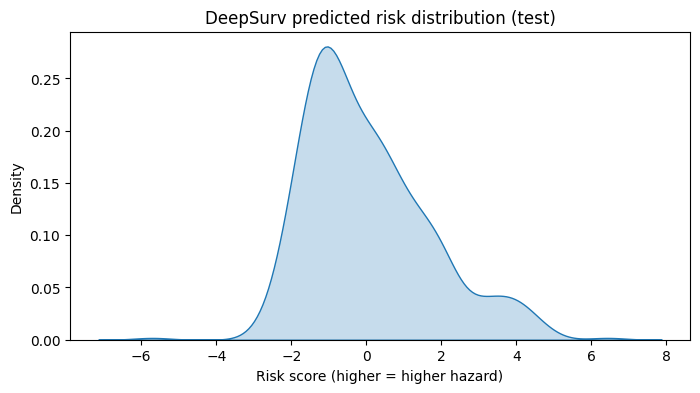

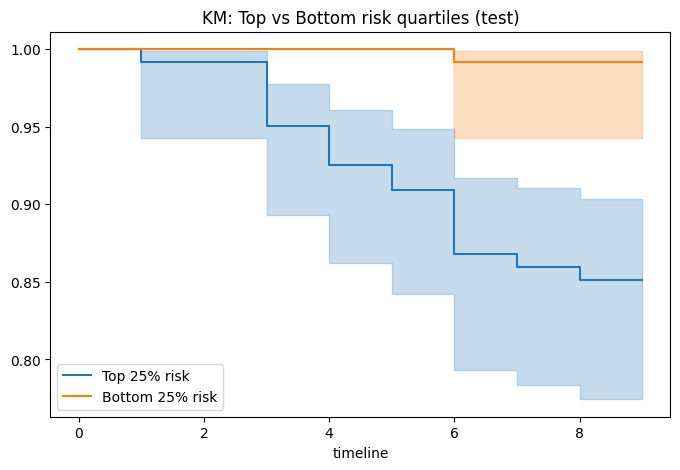

In [6]:
# Plot risk distribution
plt.figure(figsize=(8,4))
sns.kdeplot(risk_scores, fill=True)
plt.title("DeepSurv predicted risk distribution (test)")
plt.xlabel("Risk score (higher = higher hazard)")
plt.show()

# KM curves for high vs low risk groups
from lifelines import KaplanMeierFitter
df_test = pd.DataFrame({'t': t_test, 'e': e_test, 'risk': risk_scores})
high = df_test[df_test['risk'] >= df_test['risk'].quantile(0.75)]
low = df_test[df_test['risk'] <= df_test['risk'].quantile(0.25)]

km = KaplanMeierFitter()
plt.figure(figsize=(8,5))
km.fit(high['t'], event_observed=high['e'], label='Top 25% risk')
ax = km.plot(ci_show=True)
km.fit(low['t'], event_observed=low['e'], label='Bottom 25% risk')
km.plot(ci_show=True, ax=ax)
plt.title("KM: Top vs Bottom risk quartiles (test)")
plt.show()


DEEPSURV CALIBRATION PLOT

Calculating calibration on test set...


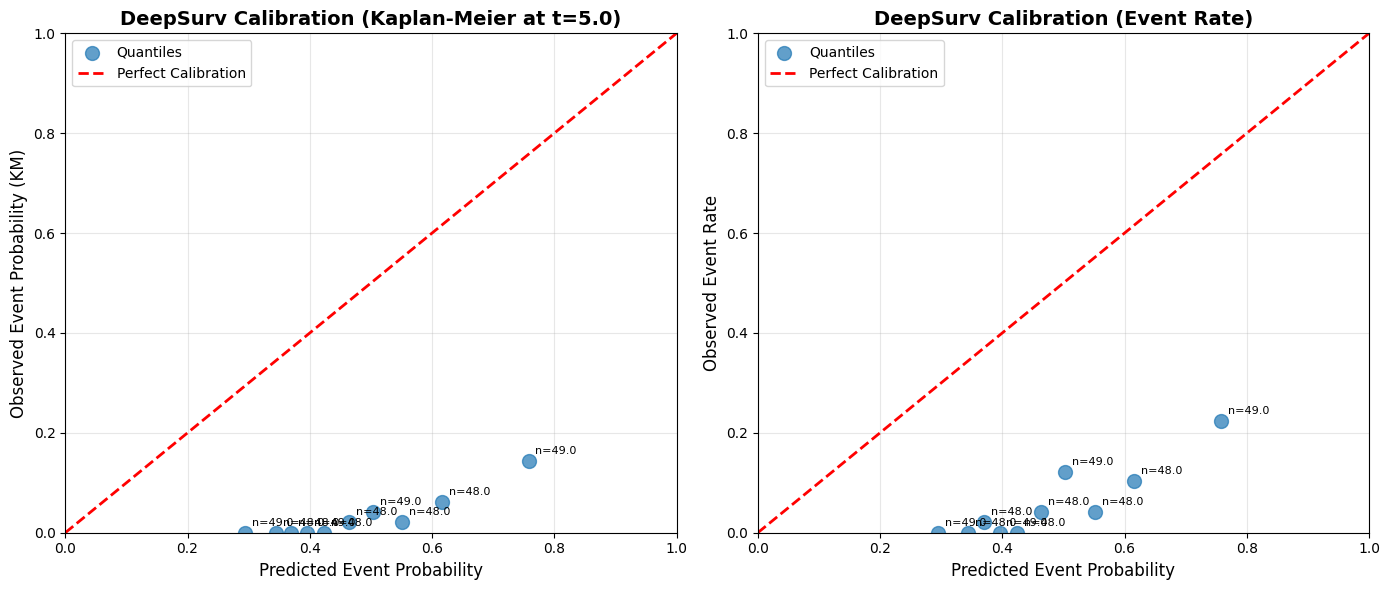


DeepSurv Calibration Metrics:
  MSE (KM-based): 0.2055
  MSE (Event Rate): 0.1793
  Mean Absolute Error (KM): 0.4433
  Mean Absolute Error (Event Rate): 0.4165


In [7]:
# Calibration plots for DeepSurv and DeepHit
from lifelines import KaplanMeierFitter

def plot_calibration_survival(risk_scores, durations, events, model_name, n_bins=10, time_point=None):
    """
    Create calibration plot for survival model.
    
    Parameters:
    - risk_scores: predicted risk scores (higher = higher risk)
    - durations: actual time to event or censoring
    - events: event indicators (1 = event, 0 = censored)
    - model_name: name of the model for plot title
    - n_bins: number of risk quantile bins
    - time_point: specific time point to evaluate (if None, uses median time)
    """
    if time_point is None:
        # Use median observed time for events
        event_times = durations[events == 1]
        if len(event_times) > 0:
            time_point = np.median(event_times)
        else:
            time_point = np.median(durations)
    
    # Create DataFrame
    df_cal = pd.DataFrame({
        'risk': risk_scores,
        'duration': durations,
        'event': events
    })
    
    # Group into risk quantiles
    df_cal['risk_quantile'] = pd.qcut(df_cal['risk'], q=n_bins, duplicates='drop', labels=False)
    
    # Calculate predicted and observed rates for each quantile
    calibration_data = []
    
    for q in sorted(df_cal['risk_quantile'].dropna().unique()):
        subset = df_cal[df_cal['risk_quantile'] == q]
        
        # Predicted risk (mean risk score in this quantile)
        # Convert risk score to probability (assuming higher score = higher risk)
        # Normalize risk scores to [0, 1] range for this quantile
        risk_min = df_cal['risk'].min()
        risk_max = df_cal['risk'].max()
        if risk_max > risk_min:
            predicted_prob = (subset['risk'].mean() - risk_min) / (risk_max - risk_min)
        else:
            predicted_prob = 0.5
        
        # Observed event rate at time_point using Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(subset['duration'], event_observed=subset['event'])
        
        # Get survival probability at time_point
        try:
            surv_at_t = kmf.predict(time_point)
            if pd.isna(surv_at_t):
                # If prediction fails, use last known survival
                surv_at_t = kmf.survival_function_.iloc[-1, 0]
            observed_prob = 1 - surv_at_t
        except:
            # Fallback: use observed event proportion
            observed_prob = subset['event'].mean()
        
        # Alternative: observed event rate (proportion of events)
        observed_rate = subset['event'].mean()
        
        calibration_data.append({
            'quantile': q,
            'predicted': predicted_prob,
            'observed_km': observed_prob,
            'observed_rate': observed_rate,
            'n': len(subset)
        })
    
    cal_df = pd.DataFrame(calibration_data)
    
    # Create calibration plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Predicted vs Observed (KM-based)
    ax1 = axes[0]
    ax1.scatter(cal_df['predicted'], cal_df['observed_km'], s=100, alpha=0.7, label='Quantiles')
    ax1.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration', linewidth=2)
    ax1.set_xlabel('Predicted Event Probability', fontsize=12)
    ax1.set_ylabel('Observed Event Probability (KM)', fontsize=12)
    ax1.set_title(f'{model_name} Calibration (Kaplan-Meier at t={time_point:.1f})', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    
    # Add sample sizes as annotations
    for _, row in cal_df.iterrows():
        ax1.annotate(f'n={row["n"]}', 
                    xy=(row['predicted'], row['observed_km']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Plot 2: Predicted vs Observed Event Rate
    ax2 = axes[1]
    ax2.scatter(cal_df['predicted'], cal_df['observed_rate'], s=100, alpha=0.7, label='Quantiles')
    ax2.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration', linewidth=2)
    ax2.set_xlabel('Predicted Event Probability', fontsize=12)
    ax2.set_ylabel('Observed Event Rate', fontsize=12)
    ax2.set_title(f'{model_name} Calibration (Event Rate)', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1])
    
    # Add sample sizes as annotations
    for _, row in cal_df.iterrows():
        ax2.annotate(f'n={row["n"]}', 
                    xy=(row['predicted'], row['observed_rate']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate calibration metrics
    # Brier score approximation (lower is better)
    mse_km = ((cal_df['predicted'] - cal_df['observed_km'])**2).mean()
    mse_rate = ((cal_df['predicted'] - cal_df['observed_rate'])**2).mean()
    
    print(f"\n{model_name} Calibration Metrics:")
    print(f"  MSE (KM-based): {mse_km:.4f}")
    print(f"  MSE (Event Rate): {mse_rate:.4f}")
    print(f"  Mean Absolute Error (KM): {np.abs(cal_df['predicted'] - cal_df['observed_km']).mean():.4f}")
    print(f"  Mean Absolute Error (Event Rate): {np.abs(cal_df['predicted'] - cal_df['observed_rate']).mean():.4f}")
    
    return cal_df

# DeepSurv Calibration
print("="*80)
print("DEEPSURV CALIBRATION PLOT")
print("="*80)
print("\nCalculating calibration on test set...")

# Get DeepSurv risk scores on test set
model_ds.eval()
with torch.no_grad():
    Xtest_t = torch.tensor(X_test.values.astype(np.float32)).to(device)
    risk_scores_ds = model_ds(Xtest_t).cpu().numpy().flatten()

# Normalize risk scores to [0, 1] for calibration
risk_min_ds = risk_scores_ds.min()
risk_max_ds = risk_scores_ds.max()
if risk_max_ds > risk_min_ds:
    risk_scores_ds_norm = (risk_scores_ds - risk_min_ds) / (risk_max_ds - risk_min_ds)
else:
    risk_scores_ds_norm = np.ones_like(risk_scores_ds) * 0.5

cal_ds = plot_calibration_survival(
    risk_scores_ds_norm, t_test, e_test, 
    model_name='DeepSurv', n_bins=10
)

# Save calibration data
cal_ds.to_csv('deepsurv_calibration_data.csv', index=False)

Calculating permutation importance for DeepSurv...
This may take a while depending on the number of features and repeats...

Baseline C-index: 0.8961
Processing feature 50/1929...
Processing feature 100/1929...
Processing feature 150/1929...
Processing feature 200/1929...
Processing feature 250/1929...
Processing feature 300/1929...
Processing feature 350/1929...
Processing feature 400/1929...
Processing feature 450/1929...
Processing feature 500/1929...
Processing feature 550/1929...
Processing feature 600/1929...
Processing feature 650/1929...
Processing feature 700/1929...
Processing feature 750/1929...
Processing feature 800/1929...
Processing feature 850/1929...
Processing feature 900/1929...
Processing feature 950/1929...
Processing feature 1000/1929...
Processing feature 1050/1929...
Processing feature 1100/1929...
Processing feature 1150/1929...
Processing feature 1200/1929...
Processing feature 1250/1929...
Processing feature 1300/1929...
Processing feature 1350/1929...
Proces

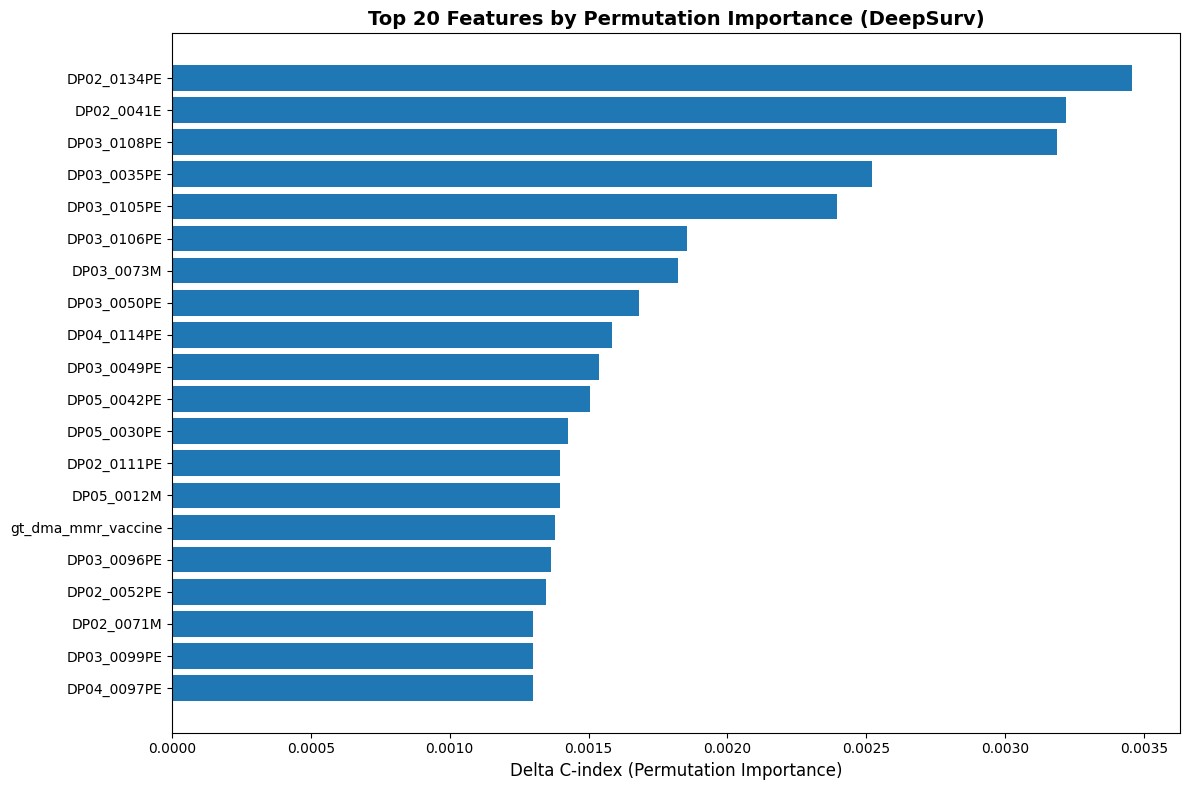


Summary Statistics:
  Mean delta C-index: 0.000016
  Median delta C-index: 0.000000
  Max delta C-index: 0.003458
  Min delta C-index: -0.001681
  Features with positive importance: 948/1929


In [8]:
# Permutation importance (model-agnostic for risk scores)
def permutation_importance_for_risk(model, X_val_df, t_val, e_val, n_repeats=10):
    """
    Calculate permutation importance for survival model.
    Returns: dict mapping feature names to delta C-index (higher = more important)
    """
    model.eval()
    with torch.no_grad():
        baseline_pred = model(torch.tensor(X_val_df.values.astype(np.float32)).to(device)).cpu().detach().numpy()
    baseline_metric = concordance_index(t_val, -baseline_pred, e_val)
    print(f"Baseline C-index: {baseline_metric:.4f}")
    
    importances = {}
    Xcopy = X_val_df.copy().reset_index(drop=True)
    total_features = len(Xcopy.columns)
    
    for idx, col in enumerate(Xcopy.columns):
        if (idx + 1) % 50 == 0:
            print(f"Processing feature {idx + 1}/{total_features}...")
        
        scores = []
        orig = Xcopy[col].values.copy()
        for _ in range(n_repeats):
            Xcopy[col] = np.random.permutation(orig)
            with torch.no_grad():
                pred_perm = model(torch.tensor(Xcopy.values.astype(np.float32)).to(device)).cpu().detach().numpy()
            scores.append(concordance_index(t_val, -pred_perm, e_val))
        importances[col] = baseline_metric - np.mean(scores)
        Xcopy[col] = orig  # Restore original values
    
    return importances

# Run permutation importance on validation set
print("Calculating permutation importance for DeepSurv...")
print("This may take a while depending on the number of features and repeats...\n")
perm_imp = permutation_importance_for_risk(model_ds, X_val, t_val, e_val, n_repeats=5)

# Sort by importance (delta C-index)
sorted_imp = sorted(perm_imp.items(), key=lambda x: x[1], reverse=True)

# Create DataFrame with feature names
# Use feature_name_mapping if available, otherwise use code
try:
    feature_names = [feature_name_mapping.get(f, f) for f, _ in sorted_imp]
except NameError:
    # If feature_name_mapping doesn't exist yet, just use codes
    feature_names = [f for f, _ in sorted_imp]

perm_imp_df = pd.DataFrame({
    'Feature Code': [f for f, _ in sorted_imp],
    'Feature Name': feature_names,
    'Delta C-index': [score for _, score in sorted_imp]
})

# Display top features
print("\n" + "="*100)
print("TOP FEATURES BY PERMUTATION IMPORTANCE (DELTA C-INDEX) FOR DEEPSURV")
print("="*100)
print(f"\nShowing top 30 features (out of {len(sorted_imp)} total):\n")
print(perm_imp_df.head(30).to_string(index=False))

# Save to CSV
perm_imp_file = 'deepsurv_permutation_importance.csv'
perm_imp_df.to_csv(perm_imp_file, index=False)
print(f"\n✓ Full results saved to {perm_imp_file}")

# Create visualization
plt.figure(figsize=(12, 8))
top_n = 20
top_features = perm_imp_df.head(top_n)
plt.barh(range(top_n), top_features['Delta C-index'].values)
plt.yticks(range(top_n), [name[:60] + '...' if len(name) > 60 else name for name in top_features['Feature Name'].values])
plt.xlabel('Delta C-index (Permutation Importance)', fontsize=12)
plt.title(f'Top {top_n} Features by Permutation Importance (DeepSurv)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSummary Statistics:")
print(f"  Mean delta C-index: {perm_imp_df['Delta C-index'].mean():.6f}")
print(f"  Median delta C-index: {perm_imp_df['Delta C-index'].median():.6f}")
print(f"  Max delta C-index: {perm_imp_df['Delta C-index'].max():.6f}")
print(f"  Min delta C-index: {perm_imp_df['Delta C-index'].min():.6f}")
print(f"  Features with positive importance: {(perm_imp_df['Delta C-index'] > 0).sum()}/{len(perm_imp_df)}")


### Random Survival Forest

In [9]:
# RSF baseline
from sksurv.util import Surv
y_struct = Surv.from_arrays(event=e_train.astype(bool), time=t_train)
rsf = RandomSurvivalForest(n_estimators=300, min_samples_split=10, n_jobs=-1, random_state=42)
rsf.fit(X_train.values, y_struct)
# predict survival function at specific times:
times_grid = np.arange(0,61)
surv_fns = rsf.predict_survival_function(X_test.values, return_array=True)
# risk at 6 months:
# Get unique event times from the model
unique_times = rsf.unique_times_
idx6 = np.searchsorted(unique_times, 6)
if idx6 >= len(unique_times):
    idx6 = len(unique_times) - 1
risk_rsf = 1 - surv_fns[:, idx6]
ci_rsf = concordance_index(t_test, -risk_rsf, e_test)
print("RSF C-index (test):", round(ci_rsf, 4))


RSF C-index (test): 0.7554


### Discrete-time model (DeepHit)

In [10]:
# DeepHit sketch (requires pycox & torchtuples)

import pycox
from pycox.models import DeepHitSingle
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
import torchtuples as tt

def train_deephit_pycox(df_train, df_val, features, nbins=60, num_nodes=[128,64], dropout=0.2, lr=1e-4, epochs=100):
    # Filter out infinity and NaN values from duration_months
    train_durations = df_train['duration_months'].values
    val_durations = df_val['duration_months'].values
    
    # Replace infinity and NaN with a large finite value (e.g., 2x the max finite value)
    train_durations_clean = train_durations[np.isfinite(train_durations)]
    val_durations_clean = val_durations[np.isfinite(val_durations)]
    
    if len(train_durations_clean) == 0 or len(val_durations_clean) == 0:
        raise ValueError("No valid (finite) duration values found in training or validation data")
    
    # Get max finite value
    max_finite = max(train_durations_clean.max(), val_durations_clean.max())
    
    # Replace infinity/NaN with 2x max finite value (for censored observations)
    train_durations = np.where(np.isfinite(train_durations), train_durations, max_finite * 2)
    val_durations = np.where(np.isfinite(val_durations), val_durations, max_finite * 2)
    
    # discretize into monthly bins up to nbins
    # Get the actual maximum duration value
    max_duration = max(train_durations.max(), val_durations.max())
    
    # Ensure max_duration is reasonable
    if not np.isfinite(max_duration) or max_duration <= 0:
        raise ValueError(f"Invalid max_duration value: {max_duration}. Check duration_months data.")
    
    # Determine number of bins: ensure it covers all durations
    # Use ceil of max_duration to ensure all values fit, but cap at 120 months (10 years)
    max_t = int(np.ceil(max_duration))
    # nbins should be at least max_t to cover all durations, but cap at 120
    nbins = min(max(nbins, 12, max_t), 120)  # At least 12, cover max_t, but cap at 120
    
    if nbins <= 0:
        raise ValueError(f"Invalid nbins value: {nbins}. Check duration_months data.")
    
    # If max_duration exceeds nbins (due to 120 cap), we need to cap durations
    # Otherwise, nbins covers all durations
    if max_duration > nbins:
        print(f"Warning: Max duration {max_duration:.1f} exceeds nbins {nbins}. Capping durations to {nbins}.")
        train_durations = np.clip(train_durations, 1.0, float(nbins))
        val_durations = np.clip(val_durations, 1.0, float(nbins))
    else:
        # Ensure all values are at least 1.0
        train_durations = np.clip(train_durations, 1.0, None)
        val_durations = np.clip(val_durations, 1.0, None)
    
    # Final safety check: ensure all values are finite and positive
    train_durations = np.where(np.isfinite(train_durations) & (train_durations >= 1.0), 
                               train_durations, 1.0)
    val_durations = np.where(np.isfinite(val_durations) & (val_durations >= 1.0), 
                             val_durations, 1.0)
    
    # Create time bins that cover the full range [1, nbins]
    time_bins = np.arange(1, nbins+1, dtype=np.float32)  # 1..nbins months
    
    # Verify ranges before passing to labtrans
    assert train_durations.min() >= 1.0 and train_durations.max() <= float(nbins), \
        f"Train durations out of range: [{train_durations.min()}, {train_durations.max()}] (nbins={nbins})"
    assert val_durations.min() >= 1.0 and val_durations.max() <= float(nbins), \
        f"Val durations out of range: [{val_durations.min()}, {val_durations.max()}] (nbins={nbins})"
    
    labtrans = LabTransDiscreteTime(time_bins)
    x_train = df_train[features].values.astype('float32')
    
    # Transform durations - pycox will discretize them into the bins
    # Note: durations are already capped to [1, nbins] so they should fit
    y_train = labtrans.fit_transform(train_durations, df_train['event'].values)
    x_val = df_val[features].values.astype('float32')
    y_val = labtrans.transform(val_durations, df_val['event'].values)

    net = tt.practical.MLPVanilla(x_train.shape[1], num_nodes, out_features=labtrans.out_features, dropout=dropout)
    model = DeepHitSingle(net, tt.optim.Adam, duration_index=labtrans.cuts)
    model.fit(x_train, y_train, batch_size=128, epochs=epochs, val_data=(x_val, y_val))
    return model, labtrans


In [11]:
# Train DeepHit model
import pycox
from pycox.models import DeepHitSingle
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
import torchtuples as tt
from pycox.evaluation import EvalSurv

# Prepare training data
df_train_deephit = pd.DataFrame({
    'duration_months': t_train,
    'event': e_train
})
df_train_deephit = pd.concat(
    [
        pd.DataFrame({"duration_months": t_train, "event": e_train}),
        X_train.reset_index(drop=True)
    ],
    axis=1
)

df_val_deephit = pd.DataFrame({
    'duration_months': t_val,
    'event': e_val
})
df_val_deephit = pd.concat(
    [
        pd.DataFrame({"duration_months": t_val, "event": e_val}),
        X_val.reset_index(drop=True)
    ],
    axis=1
)

# Train DeepHit
print("Training DeepHit model...")
model_deephit, labtrans_deephit = train_deephit_pycox(
    df_train_deephit, df_val_deephit, features, 
    nbins=20, num_nodes=[128, 64], dropout=0.2, lr=1e-4, epochs=15
)

# Evaluate on test set
print("\nEvaluating DeepHit on test set...")
x_test_deephit = X_test[features].values.astype('float32')
surv_deephit_array = model_deephit.predict_surv(x_test_deephit)

# Convert numpy array to DataFrame with time bins as index (required by EvalSurv)
time_bins = labtrans_deephit.cuts
surv_deephit = pd.DataFrame(surv_deephit_array.T, index=time_bins)

# Calculate risk scores (1 - survival at median time)
median_time_idx = len(time_bins) // 2
risk_deephit_test = 1 - surv_deephit_array[:, median_time_idx]

# Calculate C-index using pycox
durations_test = t_test
events_test = e_test.astype(bool)
ev = EvalSurv(surv_deephit, durations_test, events_test, censor_surv='km')
ci_deephit = ev.concordance_td('antolini')
print(f"DeepHit C-index (test): {ci_deephit:.4f}")

print("✓ DeepHit model trained successfully!")


Training DeepHit model...


/Users/amywang/JHU/Data Mining/measles-outbreak-timing/.venv/lib/python3.13/site-packages/pycox/preprocessing/label_transforms.py:113: UserWarning: Calling fit method, when 'cuts' are already defined. Leaving cuts unchanged.
  warnings.warn("Calling fit method, when 'cuts' are already defined. Leaving cuts unchanged.")


0:	[0s / 0s],		train_loss: 0.1996,	val_loss: 0.1667
1:	[0s / 0s],		train_loss: 0.1641,	val_loss: 0.1502
2:	[0s / 0s],		train_loss: 0.1634,	val_loss: 0.1541
3:	[0s / 0s],		train_loss: 0.1368,	val_loss: 0.1288
4:	[0s / 0s],		train_loss: 0.1200,	val_loss: 0.1166
5:	[0s / 0s],		train_loss: 0.1107,	val_loss: 0.1062
6:	[0s / 0s],		train_loss: 0.1014,	val_loss: 0.1013
7:	[0s / 0s],		train_loss: 0.0897,	val_loss: 0.0920
8:	[0s / 0s],		train_loss: 0.0821,	val_loss: 0.0864
9:	[0s / 1s],		train_loss: 0.0764,	val_loss: 0.0843
10:	[0s / 1s],		train_loss: 0.0728,	val_loss: 0.0785
11:	[0s / 1s],		train_loss: 0.0709,	val_loss: 0.0832
12:	[0s / 1s],		train_loss: 0.0658,	val_loss: 0.0773
13:	[0s / 1s],		train_loss: 0.0652,	val_loss: 0.0781
14:	[0s / 1s],		train_loss: 0.0623,	val_loss: 0.0755

Evaluating DeepHit on test set...
DeepHit C-index (test): 0.7740
✓ DeepHit model trained successfully!


Calculating permutation importance for DeepHit...
This may take a while depending on the number of features and repeats...

Baseline C-index: 0.9155
Processing feature 50/1929...
Processing feature 100/1929...
Processing feature 150/1929...
Processing feature 200/1929...
Processing feature 250/1929...
Processing feature 300/1929...
Processing feature 350/1929...
Processing feature 400/1929...
Processing feature 450/1929...
Processing feature 500/1929...
Processing feature 550/1929...
Processing feature 600/1929...
Processing feature 650/1929...
Processing feature 700/1929...
Processing feature 750/1929...
Processing feature 800/1929...
Processing feature 850/1929...
Processing feature 900/1929...
Processing feature 950/1929...
Processing feature 1000/1929...
Processing feature 1050/1929...
Processing feature 1100/1929...
Processing feature 1150/1929...
Processing feature 1200/1929...
Processing feature 1250/1929...
Processing feature 1300/1929...
Processing feature 1350/1929...
Process

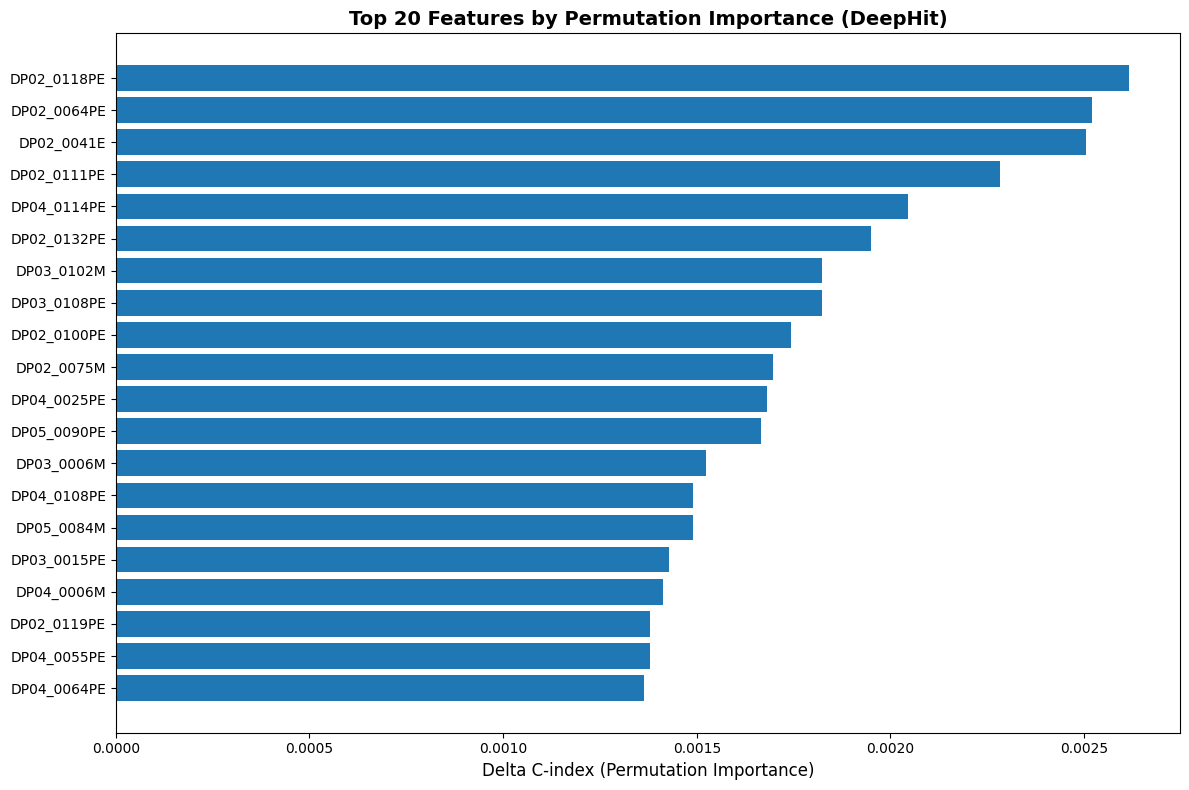


Summary Statistics:
  Mean delta C-index: 0.000035
  Median delta C-index: 0.000032
  Max delta C-index: 0.002617
  Min delta C-index: -0.003489
  Features with positive importance: 1016/1929


In [12]:
# Permutation importance for DeepHit (using survival functions)
def permutation_importance_for_deephit(model, labtrans, X_val_df, t_val, e_val, n_repeats=10):
    """
    Calculate permutation importance for DeepHit model.
    Uses survival functions and C-index from pycox evaluation.
    Returns: dict mapping feature names to delta C-index (higher = more important)
    """
    from pycox.evaluation import EvalSurv
    
    # Baseline prediction
    x_val = X_val_df[features].values.astype('float32')
    surv_baseline = model.predict_surv(x_val)
    time_bins = labtrans.cuts
    surv_df_baseline = pd.DataFrame(surv_baseline.T, index=time_bins)
    
    # Calculate baseline C-index
    ev_baseline = EvalSurv(surv_df_baseline, t_val, e_val.astype(bool), censor_surv='km')
    baseline_metric = ev_baseline.concordance_td('antolini')
    print(f"Baseline C-index: {baseline_metric:.4f}")
    
    importances = {}
    Xcopy = X_val_df.copy().reset_index(drop=True)
    total_features = len(Xcopy.columns)
    
    for idx, col in enumerate(Xcopy.columns):
        if (idx + 1) % 50 == 0:
            print(f"Processing feature {idx + 1}/{total_features}...")
        
        scores = []
        orig = Xcopy[col].values.copy()
        for _ in range(n_repeats):
            Xcopy[col] = np.random.permutation(orig)
            x_perm = Xcopy[features].values.astype('float32')
            surv_perm = model.predict_surv(x_perm)
            surv_df_perm = pd.DataFrame(surv_perm.T, index=time_bins)
            ev_perm = EvalSurv(surv_df_perm, t_val, e_val.astype(bool), censor_surv='km')
            scores.append(ev_perm.concordance_td('antolini'))
        importances[col] = baseline_metric - np.mean(scores)
        Xcopy[col] = orig  # Restore original values
    
    return importances

# Run permutation importance on validation set
print("Calculating permutation importance for DeepHit...")
print("This may take a while depending on the number of features and repeats...\n")
perm_imp_deephit = permutation_importance_for_deephit(
    model_deephit, labtrans_deephit, X_val, t_val, e_val, n_repeats=5
)

# Sort by importance (delta C-index)
sorted_imp_deephit = sorted(perm_imp_deephit.items(), key=lambda x: x[1], reverse=True)

# Create DataFrame with feature names
# Use feature_name_mapping if available, otherwise use code
try:
    feature_names_deephit = [feature_name_mapping.get(f, f) for f, _ in sorted_imp_deephit]
except NameError:
    # If feature_name_mapping doesn't exist yet, just use codes
    feature_names_deephit = [f for f, _ in sorted_imp_deephit]

perm_imp_deephit_df = pd.DataFrame({
    'Feature Code': [f for f, _ in sorted_imp_deephit],
    'Feature Name': feature_names_deephit,
    'Delta C-index': [score for _, score in sorted_imp_deephit]
})

# Display top features
print("\n" + "="*100)
print("TOP FEATURES BY PERMUTATION IMPORTANCE (DELTA C-INDEX) FOR DEEPHIT")
print("="*100)
print(f"\nShowing top 30 features (out of {len(sorted_imp_deephit)} total):\n")
print(perm_imp_deephit_df.head(30).to_string(index=False))

# Save to CSV
perm_imp_deephit_file = 'deephit_permutation_importance.csv'
perm_imp_deephit_df.to_csv(perm_imp_deephit_file, index=False)
print(f"\n✓ Full results saved to {perm_imp_deephit_file}")

# Create visualization
plt.figure(figsize=(12, 8))
top_n = 20
top_features_deephit = perm_imp_deephit_df.head(top_n)
plt.barh(range(top_n), top_features_deephit['Delta C-index'].values)
plt.yticks(range(top_n), [name[:60] + '...' if len(name) > 60 else name for name in top_features_deephit['Feature Name'].values])
plt.xlabel('Delta C-index (Permutation Importance)', fontsize=12)
plt.title(f'Top {top_n} Features by Permutation Importance (DeepHit)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSummary Statistics:")
print(f"  Mean delta C-index: {perm_imp_deephit_df['Delta C-index'].mean():.6f}")
print(f"  Median delta C-index: {perm_imp_deephit_df['Delta C-index'].median():.6f}")
print(f"  Max delta C-index: {perm_imp_deephit_df['Delta C-index'].max():.6f}")
print(f"  Min delta C-index: {perm_imp_deephit_df['Delta C-index'].min():.6f}")
print(f"  Features with positive importance: {(perm_imp_deephit_df['Delta C-index'] > 0).sum()}/{len(perm_imp_deephit_df)}")


In [13]:
# Compute time-dependent AUC at 3 and 6 months
# pycox.evaluation.EvalSurv(surv_df, times, event, censor_surv='km')

# If you use pycox/EvalSurv you can pass survival functions directly.
print("If using pycox, use pycox.evaluation.EvalSurv(surv_df, times, event, censor_surv='km') and call auc_at_times([3,6]).")
print("Otherwise you can compute time-dependent AUC with scikit-survival's cumulative_dynamic_auc or implement IPCW.")


If using pycox, use pycox.evaluation.EvalSurv(surv_df, times, event, censor_surv='km') and call auc_at_times([3,6]).
Otherwise you can compute time-dependent AUC with scikit-survival's cumulative_dynamic_auc or implement IPCW.



DEEPHIT CALIBRATION PLOT

Calculating calibration on test set...


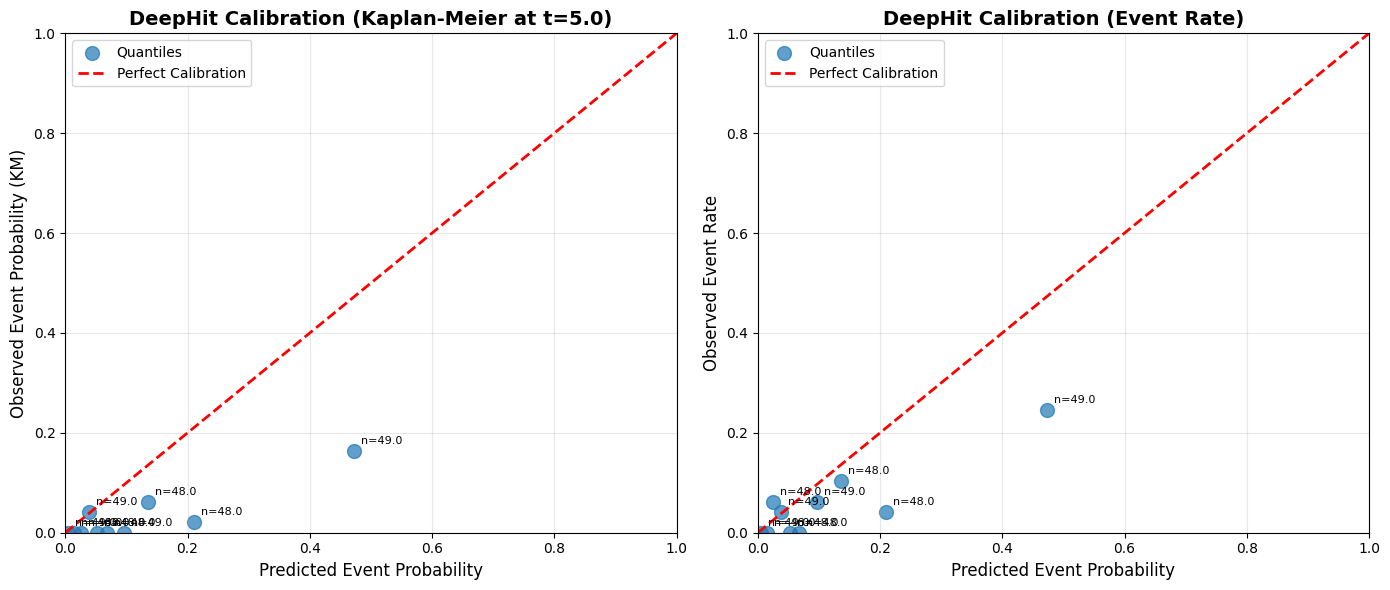


DeepHit Calibration Metrics:
  MSE (KM-based): 0.0155
  MSE (Event Rate): 0.0092
  Mean Absolute Error (KM): 0.0836
  Mean Absolute Error (Event Rate): 0.0642

✓ Calibration data saved to CSV files


In [14]:
# DeepHit Calibration
print("\n" + "="*80)
print("DEEPHIT CALIBRATION PLOT")
print("="*80)
print("\nCalculating calibration on test set...")

# Get DeepHit risk scores on test set
x_test_deephit = X_test[features].values.astype('float32')
surv_deephit_test = model_deephit.predict_surv(x_test_deephit)
time_bins_deephit = labtrans_deephit.cuts

# Calculate risk as 1 - survival at median time
median_time_idx = len(time_bins_deephit) // 2
risk_scores_dh = 1 - surv_deephit_test[:, median_time_idx]

# Risk scores are already in [0, 1] range
cal_dh = plot_calibration_survival(
    risk_scores_dh, t_test, e_test,
    model_name='DeepHit', n_bins=10
)

# Save calibration data
cal_dh.to_csv('deephit_calibration_data.csv', index=False)
print("\n✓ Calibration data saved to CSV files")


### Hyperparameter tuning (Optuna sketch)
Tune:
- architecture: number of layers & units (e.g., [64,32], [128,64], [256,128])
- dropout: 0.0 — 0.5
- learning rate: 1e-4 — 5e-3 (log)
- weight decay: 1e-6 — 1e-3
- batch size: 64 — 512
Objective: maximize validation C-index (or weighted combination of C-index and tAUC mean at 3/6 months).

Use `optuna` to run trials; for each trial call `train_deepsurv` with smaller epochs (for speed), then re-train best config with full epochs.


In [15]:
# Generate risk rankings and time-to-outbreak predictions for all counties
# This will create ranked lists showing which counties are most at risk

def predict_time_to_outbreak_deepsurv(model, X_df, max_time=72):
    """
    Predict time to outbreak using DeepSurv risk scores.
    Higher risk = shorter expected time to outbreak.
    We'll use a simple conversion: time = max_time * exp(-normalized_risk)
    """
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_df.values.astype(np.float32)).to(device)
        risk_scores = model(X_tensor).cpu().numpy()
    
    # Normalize risk scores to [0, 1] range
    risk_min, risk_max = risk_scores.min(), risk_scores.max()
    if risk_max > risk_min:
        normalized_risk = (risk_scores - risk_min) / (risk_max - risk_min)
    else:
        normalized_risk = np.ones_like(risk_scores) * 0.5
    
    # Convert risk to expected time: higher risk = shorter time
    # Using exponential decay: time = max_time * exp(-alpha * risk)
    # where alpha controls the decay rate
    alpha = 2.0  # Adjust this to control sensitivity
    predicted_time = max_time * np.exp(-alpha * normalized_risk)
    
    return risk_scores, predicted_time

def predict_time_to_outbreak_rsf(rsf_model, X_df, max_time=72):
    """
    Predict time to outbreak using RSF survival functions.
    Returns median survival time (time when S(t) = 0.5) as predicted time.
    """
    surv_fns = rsf_model.predict_survival_function(X_df.values, return_array=True)
    unique_times = rsf_model.unique_times_
    
    # Calculate risk scores (1 - survival at median time)
    median_idx = len(unique_times) // 2
    risk_scores = 1 - surv_fns[:, median_idx]
    
    # Find median survival time (time when S(t) <= 0.5)
    predicted_times = []
    for i, surv_fn in enumerate(surv_fns):
        # Find first time where survival <= 0.5
        below_median = np.where(surv_fn <= 0.5)[0]
        if len(below_median) > 0:
            pred_time = unique_times[below_median[0]]
        else:
            # If survival never drops below 0.5, use max time
            pred_time = max_time
        predicted_times.append(pred_time)
    
    return risk_scores, np.array(predicted_times)

def predict_time_to_outbreak_deephit(deephit_model, labtrans, X_df, max_time=72):
    """
    Predict time to outbreak using DeepHit survival functions.
    Returns median survival time (time when S(t) = 0.5) as predicted time.
    """
    x_all = X_df[features].values.astype('float32')
    surv_fns = deephit_model.predict_surv(x_all)
    time_bins = labtrans.cuts
    
    # Calculate risk scores (1 - survival at median time)
    median_idx = len(time_bins) // 2
    risk_scores = 1 - surv_fns[:, median_idx]
    
    # Find median survival time (time when S(t) <= 0.5)
    predicted_times = []
    for i, surv_fn in enumerate(surv_fns):
        # Find first time where survival <= 0.5
        below_median = np.where(surv_fn <= 0.5)[0]
        if len(below_median) > 0:
            pred_time = time_bins[below_median[0]]
        else:
            # If survival never drops below 0.5, use max time
            pred_time = max_time
        predicted_times.append(pred_time)
    
    return risk_scores, np.array(predicted_times)

# Get all county data (not just test set)
print("Generating predictions for all counties...")
X_all = pd.DataFrame(scaler.transform(imputer.transform(df[features])), columns=features)

# DeepSurv predictions
risk_deepsurv, time_deepsurv = predict_time_to_outbreak_deepsurv(model_ds, X_all)
print(f"DeepSurv: Generated predictions for {len(risk_deepsurv)} counties")

# RSF predictions
risk_rsf, time_rsf = predict_time_to_outbreak_rsf(rsf, X_all)
print(f"RSF: Generated predictions for {len(risk_rsf)} counties")

# DeepHit predictions
risk_deephit, time_deephit = predict_time_to_outbreak_deephit(model_deephit, labtrans_deephit, X_all)
print(f"DeepHit: Generated predictions for {len(risk_deephit)} counties")

# Create results DataFrame
results_df = pd.DataFrame({
    'county_fips': df['county_fips'].values,
    'current_status': df['event'].map({0: 'No outbreak', 1: 'Had outbreak'}).values,
    'actual_time_to_outbreak': df['duration_months'].values,
    'deepsurv_risk_score': risk_deepsurv,
    'deepsurv_predicted_time_months': time_deepsurv,
    'deepsurv_predicted_date': pd.to_datetime('2020-01-01') + pd.to_timedelta(time_deepsurv * 30.44, unit='D'),
    'rsf_risk_score': risk_rsf,
    'rsf_predicted_time_months': time_rsf,
    'rsf_predicted_date': pd.to_datetime('2020-01-01') + pd.to_timedelta(time_rsf * 30.44, unit='D'),
    'deephit_risk_score': risk_deephit,
    'deephit_predicted_time_months': time_deephit,
    'deephit_predicted_date': pd.to_datetime('2020-01-01') + pd.to_timedelta(time_deephit * 30.44, unit='D')
})

# Add rankings
results_df['deepsurv_risk_rank'] = results_df['deepsurv_risk_score'].rank(ascending=False, method='min').astype(int)
results_df['deepsurv_time_rank'] = results_df['deepsurv_predicted_time_months'].rank(ascending=True, method='min').astype(int)
results_df['rsf_risk_rank'] = results_df['rsf_risk_score'].rank(ascending=False, method='min').astype(int)
results_df['rsf_time_rank'] = results_df['rsf_predicted_time_months'].rank(ascending=True, method='min').astype(int)
results_df['deephit_risk_rank'] = results_df['deephit_risk_score'].rank(ascending=False, method='min').astype(int)
results_df['deephit_time_rank'] = results_df['deephit_predicted_time_months'].rank(ascending=True, method='min').astype(int)

print(f"\nResults DataFrame shape: {results_df.shape}")
print(f"\nTop 10 at-risk counties (DeepSurv):")
print(results_df.nlargest(10, 'deepsurv_risk_score')[['county_fips', 'deepsurv_risk_score', 'deepsurv_predicted_time_months', 'deepsurv_predicted_date', 'current_status']])


Generating predictions for all counties...
DeepSurv: Generated predictions for 3222 counties
RSF: Generated predictions for 3222 counties
DeepHit: Generated predictions for 3222 counties

Results DataFrame shape: (3222, 18)

Top 10 at-risk counties (DeepSurv):
      county_fips  deepsurv_risk_score  deepsurv_predicted_time_months  \
2607        48165             7.058042                        9.744141   
2580        48111             6.673141                       10.211318   
2683        48317             6.466842                       10.470865   
2625        48201             6.433767                       10.513086   
2592        48135             6.254135                       10.745385   
2747        48445             6.198236                       10.818715   
2751        48453             6.044664                       11.022762   
2775        48501             5.723036                       11.462656   
261          8031             5.718900                       11.468426   

In [16]:
# Display ranked lists of most at-risk counties for each model

print("="*80)
print("DEEPSURV MODEL - TOP 20 MOST AT-RISK COUNTIES")
print("="*80)
top_deepsurv = results_df.nlargest(20, 'deepsurv_risk_score')[
    ['county_fips', 'deepsurv_risk_rank', 'deepsurv_risk_score', 
     'deepsurv_predicted_time_months', 'deepsurv_predicted_date', 'current_status']
].copy()
top_deepsurv.columns = ['County FIPS', 'Risk Rank', 'Risk Score', 'Predicted Time (months)', 
                         'Predicted Outbreak Date', 'Current Status']
print(top_deepsurv.to_string(index=False))
print(f"\nCounties predicted to have outbreak within 6 months: {(results_df['deepsurv_predicted_time_months'] <= 6).sum()}")
print(f"Counties predicted to have outbreak within 12 months: {(results_df['deepsurv_predicted_time_months'] <= 12).sum()}")

if risk_rsf is not None:
    print("\n" + "="*80)
    print("RSF MODEL - TOP 20 MOST AT-RISK COUNTIES")
    print("="*80)
    top_rsf = results_df.nlargest(20, 'rsf_risk_score')[
        ['county_fips', 'rsf_risk_rank', 'rsf_risk_score', 
         'rsf_predicted_time_months', 'rsf_predicted_date', 'current_status']
    ].copy()
    top_rsf.columns = ['County FIPS', 'Risk Rank', 'Risk Score', 'Predicted Time (months)', 
                       'Predicted Outbreak Date', 'Current Status']
    print(top_rsf.to_string(index=False))
    print(f"\nCounties predicted to have outbreak within 6 months: {(results_df['rsf_predicted_time_months'] <= 6).sum()}")
    print(f"Counties predicted to have outbreak within 12 months: {(results_df['rsf_predicted_time_months'] <= 12).sum()}")

if risk_deephit is not None:
    print("\n" + "="*80)
    print("DEEPHIT MODEL - TOP 20 MOST AT-RISK COUNTIES")
    print("="*80)
    top_deephit = results_df.nlargest(20, 'deephit_risk_score')[
        ['county_fips', 'deephit_risk_rank', 'deephit_risk_score', 
         'deephit_predicted_time_months', 'deephit_predicted_date', 'current_status']
    ].copy()
    top_deephit.columns = ['County FIPS', 'Risk Rank', 'Risk Score', 'Predicted Time (months)', 
                           'Predicted Outbreak Date', 'Current Status']
    print(top_deephit.to_string(index=False))
    print(f"\nCounties predicted to have outbreak within 6 months: {(results_df['deephit_predicted_time_months'] <= 6).sum()}")
    print(f"Counties predicted to have outbreak within 12 months: {(results_df['deephit_predicted_time_months'] <= 12).sum()}")


DEEPSURV MODEL - TOP 20 MOST AT-RISK COUNTIES
 County FIPS  Risk Rank  Risk Score  Predicted Time (months)       Predicted Outbreak Date Current Status
       48165          1    7.058042                 9.744141 2020-10-23 14:40:45.117187495   Had outbreak
       48111          2    6.673141                10.211318 2020-11-06 19:58:49.687500000   Had outbreak
       48317          3    6.466842                10.470865 2020-11-14 17:35:44.531250000   Had outbreak
       48201          4    6.433767                10.513086 2020-11-16 00:26:24.667968747   Had outbreak
       48135          5    6.254135                10.745385 2020-11-23 02:08:56.132812504   Had outbreak
       48445          6    6.198236                10.818715 2020-11-25 07:43:13.652343747   Had outbreak
       48453          7    6.044664                11.022762 2020-12-01 12:47:22.382812504   Had outbreak
       48501          8    5.723036                11.462656 2020-12-14 22:09:28.652343747   Had outbreak


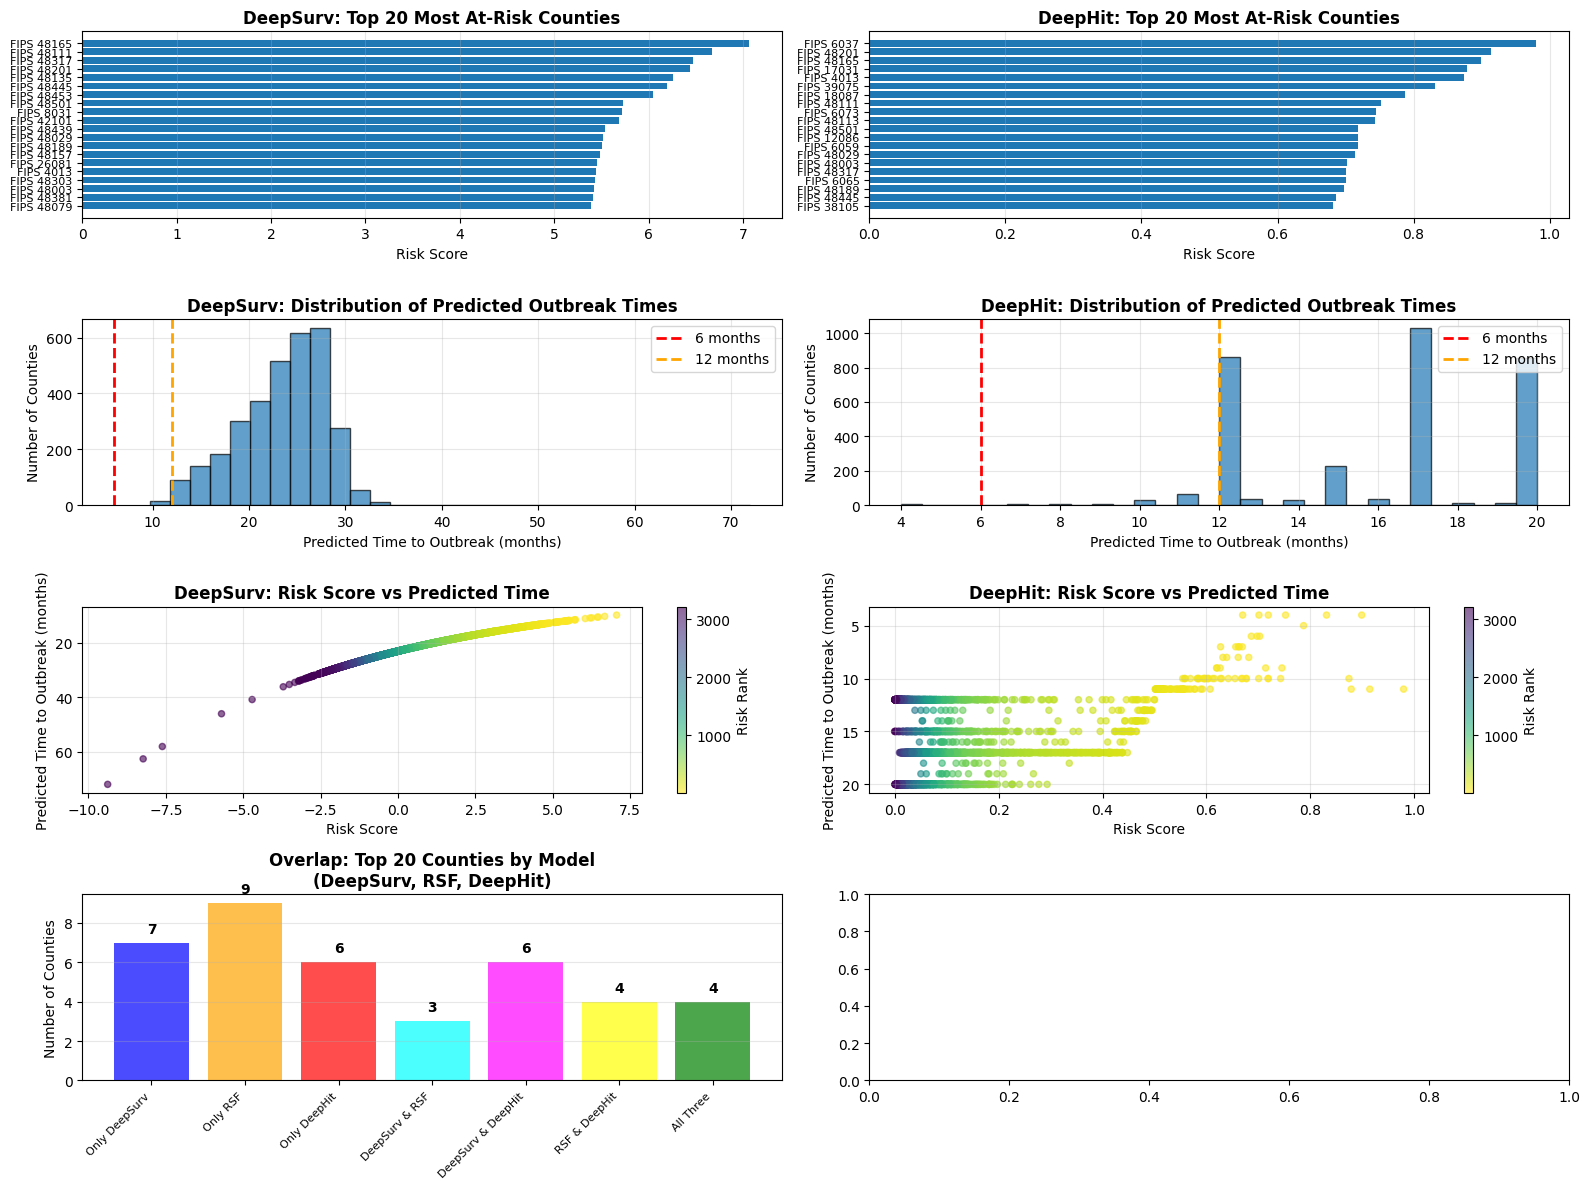


SUMMARY STATISTICS

DeepSurv Model:
  Mean predicted time to outbreak: 23.54 months
  Median predicted time to outbreak: 24.24 months
  Counties with predicted outbreak < 3 months: 0
  Counties with predicted outbreak < 6 months: 0
  Counties with predicted outbreak < 12 months: 22

RSF Model:
  Mean predicted time to outbreak: 70.60 months
  Median predicted time to outbreak: 72.00 months
  Counties with predicted outbreak < 3 months: 0
  Counties with predicted outbreak < 6 months: 33
  Counties with predicted outbreak < 12 months: 68

DeepHit Model:
  Mean predicted time to outbreak: 15.99 months
  Median predicted time to outbreak: 17.00 months
  Counties with predicted outbreak < 3 months: 0
  Counties with predicted outbreak < 6 months: 7
  Counties with predicted outbreak < 12 months: 117


In [17]:
# Visualize risk rankings and predicted outbreak times

fig, axes = plt.subplots(4, 2, figsize=(16, 12))

# Top 20 counties by risk (DeepSurv)
ax1 = axes[0, 0]
top_20 = results_df.nlargest(20, 'deepsurv_risk_score')
ax1.barh(range(len(top_20)), top_20['deepsurv_risk_score'].values)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels([f"FIPS {fips}" for fips in top_20['county_fips'].values], fontsize=8)
ax1.set_xlabel('Risk Score', fontsize=10)
ax1.set_title('DeepSurv: Top 20 Most At-Risk Counties', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Predicted time to outbreak distribution (DeepSurv)
ax2 = axes[1, 0]
ax2.hist(results_df['deepsurv_predicted_time_months'], bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=6, color='red', linestyle='--', label='6 months', linewidth=2)
ax2.axvline(x=12, color='orange', linestyle='--', label='12 months', linewidth=2)
ax2.set_xlabel('Predicted Time to Outbreak (months)', fontsize=10)
ax2.set_ylabel('Number of Counties', fontsize=10)
ax2.set_title('DeepSurv: Distribution of Predicted Outbreak Times', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Risk vs Predicted Time scatter (DeepSurv)
ax3 = axes[2, 0]
scatter = ax3.scatter(results_df['deepsurv_risk_score'], results_df['deepsurv_predicted_time_months'], 
                     c=results_df['deepsurv_risk_rank'], cmap='viridis_r', alpha=0.6, s=20)
ax3.set_xlabel('Risk Score', fontsize=10)
ax3.set_ylabel('Predicted Time to Outbreak (months)', fontsize=10)
ax3.set_title('DeepSurv: Risk Score vs Predicted Time', fontsize=12, fontweight='bold')
ax3.invert_yaxis()  # Lower time = higher risk
plt.colorbar(scatter, ax=ax3, label='Risk Rank')
ax3.grid(alpha=0.3)

# Top 20 counties by risk (DeepHit)
ax1 = axes[0, 1]
top_20 = results_df.nlargest(20, 'deephit_risk_score')
ax1.barh(range(len(top_20)), top_20['deephit_risk_score'].values)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels([f"FIPS {fips}" for fips in top_20['county_fips'].values], fontsize=8)
ax1.set_xlabel('Risk Score', fontsize=10)
ax1.set_title('DeepHit: Top 20 Most At-Risk Counties', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Predicted time to outbreak distribution (DeepHit)
ax2 = axes[1, 1]
ax2.hist(results_df['deephit_predicted_time_months'], bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=6, color='red', linestyle='--', label='6 months', linewidth=2)
ax2.axvline(x=12, color='orange', linestyle='--', label='12 months', linewidth=2)
ax2.set_xlabel('Predicted Time to Outbreak (months)', fontsize=10)
ax2.set_ylabel('Number of Counties', fontsize=10)
ax2.set_title('DeepHit: Distribution of Predicted Outbreak Times', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Risk vs Predicted Time scatter (DeepHit)
ax3 = axes[2, 1]
scatter = ax3.scatter(results_df['deephit_risk_score'], results_df['deephit_predicted_time_months'], 
                     c=results_df['deephit_risk_rank'], cmap='viridis_r', alpha=0.6, s=20)
ax3.set_xlabel('Risk Score', fontsize=10)
ax3.set_ylabel('Predicted Time to Outbreak (months)', fontsize=10)
ax3.set_title('DeepHit: Risk Score vs Predicted Time', fontsize=12, fontweight='bold')
ax3.invert_yaxis()  # Lower time = higher risk
plt.colorbar(scatter, ax=ax3, label='Risk Rank')
ax3.grid(alpha=0.3)


# Comparison of top counties between models
ax4 = axes[3, 0]
top_deepsurv_fips = set(results_df.nlargest(20, 'deepsurv_risk_score')['county_fips'].values)
models_available = ['DeepSurv']
labels = ['Only DeepSurv']
counts = [len(top_deepsurv_fips)]
colors = ['blue']

if risk_rsf is not None:
    top_rsf_fips = set(results_df.nlargest(20, 'rsf_risk_score')['county_fips'].values)
    models_available.append('RSF')
    labels.extend(['Only RSF', 'DeepSurv & RSF'])
    counts.extend([
        len(top_rsf_fips - top_deepsurv_fips),
        len(top_deepsurv_fips & top_rsf_fips)
    ])
    colors.extend(['orange', 'green'])

if risk_deephit is not None:
    top_deephit_fips = set(results_df.nlargest(20, 'deephit_risk_score')['county_fips'].values)
    models_available.append('DeepHit')
    if len(models_available) == 2:  # Only DeepSurv and DeepHit
        labels = ['Only DeepSurv', 'Only DeepHit', 'Both']
        counts = [
            len(top_deepsurv_fips - top_deephit_fips),
            len(top_deephit_fips - top_deepsurv_fips),
            len(top_deepsurv_fips & top_deephit_fips)
        ]
        colors = ['blue', 'red', 'green']
    elif len(models_available) == 3:  # All three models
        labels = ['Only DeepSurv', 'Only RSF', 'Only DeepHit', 
                  'DeepSurv & RSF', 'DeepSurv & DeepHit', 'RSF & DeepHit', 'All Three']
        counts = [
            len(top_deepsurv_fips - top_rsf_fips - top_deephit_fips),
            len(top_rsf_fips - top_deepsurv_fips - top_deephit_fips),
            len(top_deephit_fips - top_deepsurv_fips - top_rsf_fips),
            len((top_deepsurv_fips & top_rsf_fips) - top_deephit_fips),
            len((top_deepsurv_fips & top_deephit_fips) - top_rsf_fips),
            len((top_rsf_fips & top_deephit_fips) - top_deepsurv_fips),
            len(top_deepsurv_fips & top_rsf_fips & top_deephit_fips)
        ]
        colors = ['blue', 'orange', 'red', 'cyan', 'magenta', 'yellow', 'green']

if len(labels) > 0:
    ax4.bar(range(len(labels)), counts, color=colors[:len(labels)], alpha=0.7)
    ax4.set_xticks(range(len(labels)))
    ax4.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax4.set_ylabel('Number of Counties', fontsize=10)
    ax4.set_title(f'Overlap: Top 20 Counties by Model\n({", ".join(models_available)})', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    for i, v in enumerate(counts):
        ax4.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'No additional models available', 
             ha='center', va='center', fontsize=14, transform=ax4.transAxes)
    ax4.set_title('Model Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\nDeepSurv Model:")
print(f"  Mean predicted time to outbreak: {results_df['deepsurv_predicted_time_months'].mean():.2f} months")
print(f"  Median predicted time to outbreak: {results_df['deepsurv_predicted_time_months'].median():.2f} months")
print(f"  Counties with predicted outbreak < 3 months: {(results_df['deepsurv_predicted_time_months'] < 3).sum()}")
print(f"  Counties with predicted outbreak < 6 months: {(results_df['deepsurv_predicted_time_months'] < 6).sum()}")
print(f"  Counties with predicted outbreak < 12 months: {(results_df['deepsurv_predicted_time_months'] < 12).sum()}")

if risk_rsf is not None:
    print(f"\nRSF Model:")
    print(f"  Mean predicted time to outbreak: {results_df['rsf_predicted_time_months'].mean():.2f} months")
    print(f"  Median predicted time to outbreak: {results_df['rsf_predicted_time_months'].median():.2f} months")
    print(f"  Counties with predicted outbreak < 3 months: {(results_df['rsf_predicted_time_months'] < 3).sum()}")
    print(f"  Counties with predicted outbreak < 6 months: {(results_df['rsf_predicted_time_months'] < 6).sum()}")
    print(f"  Counties with predicted outbreak < 12 months: {(results_df['rsf_predicted_time_months'] < 12).sum()}")

if risk_deephit is not None:
    print(f"\nDeepHit Model:")
    print(f"  Mean predicted time to outbreak: {results_df['deephit_predicted_time_months'].mean():.2f} months")
    print(f"  Median predicted time to outbreak: {results_df['deephit_predicted_time_months'].median():.2f} months")
    print(f"  Counties with predicted outbreak < 3 months: {(results_df['deephit_predicted_time_months'] < 3).sum()}")
    print(f"  Counties with predicted outbreak < 6 months: {(results_df['deephit_predicted_time_months'] < 6).sum()}")
    print(f"  Counties with predicted outbreak < 12 months: {(results_df['deephit_predicted_time_months'] < 12).sum()}")


In [18]:
# Top 10 counties with the most total risk between all models
overlap_df = results_df.copy()
overlap_df['total_risk'] = overlap_df['deepsurv_risk_score'] + overlap_df['rsf_risk_score'] + overlap_df['deephit_risk_score']
overlap_df = overlap_df.nlargest(10, 'total_risk')
overlap_df


,county_fips,current_status,actual_time_to_outbreak,deepsurv_risk_score,deepsurv_predicted_time_months,deepsurv_predicted_date,rsf_risk_score,rsf_predicted_time_months,rsf_predicted_date,deephit_risk_score,deephit_predicted_time_months,deephit_predicted_date,deepsurv_risk_rank,deepsurv_time_rank,rsf_risk_rank,rsf_time_rank,deephit_risk_rank,deephit_time_rank,total_risk
2607,48165,Had outbreak,2,7.058042,9.744141,2020-10-23 14:40:45.117187495,0.582376,4.0,2020-05-01 18:14:24.000000000,0.898754,4.0,2020-05-01 18:14:24.184570315,1,1,15,4,3,1,8.539171
2580,48111,Had outbreak,2,6.673141,10.211318,2020-11-06 19:58:49.687500000,0.609827,4.0,2020-05-01 18:14:24.000000000,0.752281,4.0,2020-05-01 18:14:24.184570315,2,2,11,4,8,1,8.035248
2625,48201,Had outbreak,1,6.433767,10.513086,2020-11-16 00:26:24.667968747,0.614370,4.0,2020-05-01 18:14:24.000000000,0.914322,11.0,2020-11-30 20:09:35.683593747,4,4,10,4,2,55,7.962459
2683,48317,Had outbreak,2,6.466842,10.470865,2020-11-14 17:35:44.531250000,0.456978,72.0,2025-12-31 16:19:12.000000025,0.701090,4.0,2020-05-01 18:14:24.184570315,3,3,46,69,16,1,7.624909
2592,48135,Had outbreak,2,6.254135,10.745385,2020-11-23 02:08:56.132812504,0.554284,5.0,2020-06-01 04:48:00.000000000,0.663253,7.0,2020-08-01 01:55:12.158203126,5,5,20,24,27,11,7.471672
2747,48445,Had outbreak,2,6.198236,10.818715,2020-11-25 07:43:13.652343747,0.551207,4.0,2020-05-01 18:14:24.000000000,0.686376,6.0,2020-07-01 15:21:35.947265621,6,6,21,4,19,8,7.435820
2751,48453,Had outbreak,3,6.044664,11.022762,2020-12-01 12:47:22.382812504,0.460012,6.0,2020-07-01 15:21:36.000000000,0.585766,10.0,2020-10-31 09:35:59.472656252,7,7,43,34,53,25,7.090442
2775,48501,Had outbreak,2,5.723036,11.462656,2020-12-14 22:09:28.652343747,0.589072,4.0,2020-05-01 18:14:24.000000000,0.719003,4.0,2020-05-01 18:14:24.184570315,8,8,14,4,11,1,7.031112
2296,42101,Had outbreak,3,5.688112,11.511466,2020-12-16 09:48:59.941406252,0.580622,4.0,2020-05-01 18:14:24.000000000,0.597276,10.0,2020-10-31 09:35:59.472656252,10,10,16,4,47,25,6.866009
104,4013,No outbreak,9,5.445505,11.856322,2020-12-26 21:45:18.457031252,0.417880,6.0,2020-07-01 15:21:36.000000000,0.874246,10.0,2020-10-31 09:35:59.472656252,16,16,57,34,5,25,6.737631


In [19]:
# Export results to CSV files

# Export full results
output_file = 'county_risk_predictions_all.csv'
results_df.to_csv(output_file, index=False)
print(f"✓ Exported full results to {output_file}")
print(f"  Total counties: {len(results_df)}")

# Export top 50 at-risk counties for DeepSurv
top50_deepsurv = results_df.nlargest(50, 'deepsurv_risk_score')[
    ['county_fips', 'deepsurv_risk_rank', 'deepsurv_risk_score', 
     'deepsurv_predicted_time_months', 'deepsurv_predicted_date', 'current_status']
].copy()
top50_deepsurv.columns = ['county_fips', 'risk_rank', 'risk_score', 
                          'predicted_time_months', 'predicted_outbreak_date', 'current_status']
top50_deepsurv_file = 'top50_at_risk_counties_deepsurv.csv'
top50_deepsurv.to_csv(top50_deepsurv_file, index=False)
print(f"✓ Exported top 50 at-risk counties (DeepSurv) to {top50_deepsurv_file}")

# Export top 50 at-risk counties for RSF (if available)
if risk_rsf is not None:
    top50_rsf = results_df.nlargest(50, 'rsf_risk_score')[
        ['county_fips', 'rsf_risk_rank', 'rsf_risk_score', 
         'rsf_predicted_time_months', 'rsf_predicted_date', 'current_status']
    ].copy()
    top50_rsf.columns = ['county_fips', 'risk_rank', 'risk_score', 
                        'predicted_time_months', 'predicted_outbreak_date', 'current_status']
    top50_rsf_file = 'top50_at_risk_counties_rsf.csv'
    top50_rsf.to_csv(top50_rsf_file, index=False)
    print(f"✓ Exported top 50 at-risk counties (RSF) to {top50_rsf_file}")

# Export top 50 at-risk counties for DeepHit (if available)
if risk_deephit is not None:
    top50_deephit = results_df.nlargest(50, 'deephit_risk_score')[
        ['county_fips', 'deephit_risk_rank', 'deephit_risk_score', 
         'deephit_predicted_time_months', 'deephit_predicted_date', 'current_status']
    ].copy()
    top50_deephit.columns = ['county_fips', 'risk_rank', 'risk_score', 
                             'predicted_time_months', 'predicted_outbreak_date', 'current_status']
    top50_deephit_file = 'top50_at_risk_counties_deephit.csv'
    top50_deephit.to_csv(top50_deephit_file, index=False)
    print(f"✓ Exported top 50 at-risk counties (DeepHit) to {top50_deephit_file}")

# Export counties predicted to have outbreak within 6 months
urgent_deepsurv = results_df[results_df['deepsurv_predicted_time_months'] <= 6].sort_values('deepsurv_predicted_time_months')[
    ['county_fips', 'deepsurv_risk_rank', 'deepsurv_risk_score', 
     'deepsurv_predicted_time_months', 'deepsurv_predicted_date', 'current_status']
].copy()
urgent_deepsurv.columns = ['county_fips', 'risk_rank', 'risk_score', 
                          'predicted_time_months', 'predicted_outbreak_date', 'current_status']
urgent_file = 'urgent_counties_predicted_outbreak_6months_deepsurv.csv'
urgent_deepsurv.to_csv(urgent_file, index=False)
print(f"✓ Exported urgent counties (predicted outbreak ≤ 6 months) to {urgent_file}")
print(f"  Number of urgent counties: {len(urgent_deepsurv)}")

if risk_rsf is not None:
    urgent_rsf = results_df[results_df['rsf_predicted_time_months'] <= 6].sort_values('rsf_predicted_time_months')[
        ['county_fips', 'rsf_risk_rank', 'rsf_risk_score', 
         'rsf_predicted_time_months', 'rsf_predicted_date', 'current_status']
    ].copy()
    urgent_rsf.columns = ['county_fips', 'risk_rank', 'risk_score', 
                          'predicted_time_months', 'predicted_outbreak_date', 'current_status']
    urgent_rsf_file = 'urgent_counties_predicted_outbreak_6months_rsf.csv'
    urgent_rsf.to_csv(urgent_rsf_file, index=False)
    print(f"✓ Exported urgent counties (predicted outbreak ≤ 6 months, RSF) to {urgent_rsf_file}")
    print(f"  Number of urgent counties: {len(urgent_rsf)}")

if risk_deephit is not None:
    urgent_deephit = results_df[results_df['deephit_predicted_time_months'] <= 6].sort_values('deephit_predicted_time_months')[
        ['county_fips', 'deephit_risk_rank', 'deephit_risk_score', 
         'deephit_predicted_time_months', 'deephit_predicted_date', 'current_status']
    ].copy()
    urgent_deephit.columns = ['county_fips', 'risk_rank', 'risk_score', 
                              'predicted_time_months', 'predicted_outbreak_date', 'current_status']
    urgent_deephit_file = 'urgent_counties_predicted_outbreak_6months_deephit.csv'
    urgent_deephit.to_csv(urgent_deephit_file, index=False)
    print(f"✓ Exported urgent counties (predicted outbreak ≤ 6 months, DeepHit) to {urgent_deephit_file}")
    print(f"  Number of urgent counties: {len(urgent_deephit)}")

print("\n" + "="*80)
print("EXPORT COMPLETE")
print("="*80)
print("\nFiles created:")
print(f"  1. {output_file} - All counties with predictions")
print(f"  2. {top50_deepsurv_file} - Top 50 at-risk counties (DeepSurv)")
file_num = 3
if risk_rsf is not None:
    print(f"  {file_num}. {top50_rsf_file} - Top 50 at-risk counties (RSF)")
    file_num += 1
if risk_deephit is not None:
    print(f"  {file_num}. {top50_deephit_file} - Top 50 at-risk counties (DeepHit)")
    file_num += 1
print(f"  {file_num}. {urgent_file} - Counties with predicted outbreak ≤ 6 months (DeepSurv)")
file_num += 1
if risk_rsf is not None:
    print(f"  {file_num}. {urgent_rsf_file} - Counties with predicted outbreak ≤ 6 months (RSF)")
    file_num += 1
if risk_deephit is not None:
    print(f"  {file_num}. {urgent_deephit_file} - Counties with predicted outbreak ≤ 6 months (DeepHit)")


✓ Exported full results to county_risk_predictions_all.csv
  Total counties: 3222
✓ Exported top 50 at-risk counties (DeepSurv) to top50_at_risk_counties_deepsurv.csv
✓ Exported top 50 at-risk counties (RSF) to top50_at_risk_counties_rsf.csv
✓ Exported top 50 at-risk counties (DeepHit) to top50_at_risk_counties_deephit.csv
✓ Exported urgent counties (predicted outbreak ≤ 6 months) to urgent_counties_predicted_outbreak_6months_deepsurv.csv
  Number of urgent counties: 0
✓ Exported urgent counties (predicted outbreak ≤ 6 months, RSF) to urgent_counties_predicted_outbreak_6months_rsf.csv
  Number of urgent counties: 53
✓ Exported urgent counties (predicted outbreak ≤ 6 months, DeepHit) to urgent_counties_predicted_outbreak_6months_deephit.csv
  Number of urgent counties: 10

EXPORT COMPLETE

Files created:
  1. county_risk_predictions_all.csv - All counties with predictions
  2. top50_at_risk_counties_deepsurv.csv - Top 50 at-risk counties (DeepSurv)
  3. top50_at_risk_counties_rsf.csv - 

In [20]:
# Save model checkpoint
model_path = "deepsurv_demo_checkpoint.pth"
torch.save({'model_state': model_ds.state_dict(), 'features': features}, model_path)
print("Saved checkpoint to", model_path)

# To load:
# ckpt = torch.load(model_path, map_location='cpu')
# model_loaded = MLPNet(len(features), [128,64], dropout=0.2)
# model_loaded.load_state_dict(ckpt['model_state'])


Saved checkpoint to deepsurv_demo_checkpoint.pth


## Next steps & production considerations

1. **Run full training:** increase DeepSurv epochs (e.g., 300–1000) and tune hyperparameters.
2. **DeepHit (discrete-time):** train DeepHit using `pycox` for calibrated monthly probabilities — good for tAUC and monthly probability forecasts.
3. **Calibration:** after training, compute predicted S(3) and S(6) for all test counties; produce grouped calibration plots and consider isotonic regression or Platt scaling.
4. **Spatial features:** include neighboring counties' vaccination rates & outbreaks to capture spatial autocorrelation (e.g., lagged counts or spatial smoothing).
5. **Class imbalance:** outbreaks are rare — consider weighted loss, event oversampling, or focal-loss-like modifications.
6. **Interpretability:** use integrated gradients (for DeepSurv), SHAP (if feasible), and permutation importance (model-agnostic).
7. **Model comparison:** RSF / LightGBM_survival / CoxPH (baseline) vs DeepSurv / DeepHit. Compare with C-index, tAUC@3/6 months, calibration Brier score.
8. **Deployment:** serialize model + scaler+imputer + feature list; for discrete forecasts produce monthly hazard & survival curves per county.

If you'd like, I can:
- convert these cells into a single `.ipynb` JSON and paste it here for download,
- or run the notebook end-to-end on a user-uploaded CSV and return the outputs and saved artifacts.


In [21]:
# Feature Code to Name Mapping
# This cell creates a mapping from feature codes to their actual meanings

def load_acs_code_mapping():
    """
    Load ACS code-to-meaning mapping from the actual ACS data files.
    Row 1 of each ACS file contains the codes, Row 2 contains the meanings.
    """
    acs_mapping = {}
    
    acs_files = {
        'DP02': '../data/ACSDP5Y2023.DP02-Data.csv',
        'DP03': '../data/ACSDP5Y2023.DP03-Data.csv',
        'DP04': '../data/ACSDP5Y2023.DP04-Data.csv',
        'DP05': '../data/ACSDP5Y2023.DP05-Data.csv'
    }
    
    for prefix, filepath in acs_files.items():
        try:
            # Read first 2 rows: row 0 has codes (column headers), row 1 has meanings
            # When pandas reads CSV: first line = column names, second line = row 0
            df = pd.read_csv(filepath, nrows=2, low_memory=False)
            
            # Get column names (codes) and row 0 values (meanings from CSV row 2)
            codes = df.columns.tolist()
            meanings = df.iloc[0].values.tolist()  # First data row (CSV row 2) has meanings
            
            # Map codes to meanings
            for code, meaning in zip(codes, meanings):
                if code.startswith(prefix):
                    # Clean up the meaning string
                    meaning_str = str(meaning).strip()
                    if meaning_str and meaning_str != 'nan':
                        acs_mapping[code] = meaning_str
                        
            print(f"Loaded {len([c for c in codes if c.startswith(prefix)])} {prefix} codes")
        except Exception as e:
            print(f"Warning: Could not load {prefix} from {filepath}: {e}")
    
    return acs_mapping

def create_feature_mapping(features_list, acs_mapping=None):
    """
    Create a mapping from feature codes to human-readable names.
    Uses real ACS mappings when available.
    """
    if acs_mapping is None:
        acs_mapping = load_acs_code_mapping()
    
    feature_map = {}

    for feat in features_list:
        code = feat
        readable_name = code
        
        # Check if it's an ACS code with a known mapping
        if code in acs_mapping:
            readable_name = acs_mapping[code]
        # Check if it's an ACS code pattern but not in mapping
        elif code.startswith(('DP02_', 'DP03_', 'DP04_', 'DP05_')):
            prefix = code[:4]
            category_map = {
                'DP02': 'Social Characteristics',
                'DP03': 'Economic Characteristics',
                'DP04': 'Housing Characteristics',
                'DP05': 'Demographic Characteristics'
            }
            category = category_map.get(prefix, 'Unknown Category')
            
            # Determine variable type suffix
            if code.endswith('E'):
                var_type = ' (Estimate)'
            elif code.endswith('M'):
                var_type = ' (Margin of Error)'
            elif code.endswith('PE'):
                var_type = ' (Percent)'
            elif code.endswith('PM'):
                var_type = ' (Percent Margin of Error)'
            else:
                var_type = ''
            
            readable_name = f"{category} - {code}{var_type}"
        # Handle other common patterns
        elif code.startswith('vacc_'):
            readable_name = code.replace('vacc_', 'Vaccination: ').replace('_', ' ').title()
        elif code.startswith('google_trend'):
            readable_name = 'Google Trends Search Activity'
        elif code.startswith('intl_passengers'):
            readable_name = 'International Passenger Volume'
        elif code.startswith('sin_season') or code.startswith('cos_season'):
            readable_name = 'Seasonal Pattern (Sine/Cosine)'
        elif code.startswith('month_index'):
            readable_name = 'Time Index (Month)'
        else:
            # For unknown codes, keep the code but make it more readable
            readable_name = code.replace('_', ' ').title()

        feature_map[feat] = readable_name

    return feature_map

# Load ACS mappings first
print("Loading ACS code mappings from data files...")
acs_code_mapping = load_acs_code_mapping()
print(f"Total ACS codes loaded: {len(acs_code_mapping)}\n")

# Create the mapping using real ACS data
feature_name_mapping = create_feature_mapping(features, acs_mapping=acs_code_mapping)

print("="*80)
print("FEATURE CODE TO NAME MAPPING")
print("="*80)
print(f"\nTotal features: {len(feature_name_mapping)}\n")

# Display mapping in a readable format
mapping_df = pd.DataFrame({
    'Feature Code': list(feature_name_mapping.keys()),
    'Feature Name': list(feature_name_mapping.values())
})

# Save to CSV
mapping_file = 'feature_code_to_name_mapping.csv'
mapping_df.to_csv(mapping_file, index=False)
print(f"✓ Feature mapping saved to {mapping_file}\n")

# Display first 50 features
print("First 50 features:")
print(mapping_df.head(50).to_string(index=False))

# Group by ACS category for better organization
print("\n" + "="*80)
print("FEATURES BY CATEGORY")
print("="*80)

acs_categories = {}
other_features = []

for code, name in feature_name_mapping.items():
    # Use original column name (no prefix removal)
    if code.startswith('DP02_'):
        cat = 'DP02 - Social Characteristics'
    elif code.startswith('DP03_'):
        cat = 'DP03 - Economic Characteristics'
    elif code.startswith('DP04_'):
        cat = 'DP04 - Housing Characteristics'
    elif code.startswith('DP05_'):
        cat = 'DP05 - Demographic Characteristics'
    else:
        cat = 'Other Features'
    
    if cat not in acs_categories:
        acs_categories[cat] = []
    acs_categories[cat].append((code, name))

for cat, items in sorted(acs_categories.items()):
    print(f"\n{cat}: {len(items)} features")
    if len(items) <= 10:
        for code, name in items[:10]:
            print(f"  {code} -> {name}")
    else:
        for code, name in items[:5]:
            print(f"  {code} -> {name}")
        print(f"  ... and {len(items) - 5} more")

print("\n" + "="*80)
print("To look up a specific feature code, use: feature_name_mapping['DP03_0086E']")
print("="*80)


Loading ACS code mappings from data files...
Loaded 616 DP02 codes
Loaded 548 DP03 codes
Loaded 572 DP04 codes
Loaded 376 DP05 codes
Total ACS codes loaded: 2112

FEATURE CODE TO NAME MAPPING

Total features: 1929

✓ Feature mapping saved to feature_code_to_name_mapping.csv

First 50 features:
Feature Code                                                                                                                                          Feature Name
  DP02_0001E                                                                                                        Estimate!!HOUSEHOLDS BY TYPE!!Total households
  DP02_0001M                                                                                                 Margin of Error!!HOUSEHOLDS BY TYPE!!Total households
  DP02_0002E                                                                              Estimate!!HOUSEHOLDS BY TYPE!!Total households!!Married-couple household
  DP02_0002M                                         